# Ethiopia Food Prices — 12 EXPLAINABILITY (cereals & tubers)

`11 MODEL COMPARISON` picked **Hist Gradient Boosting** as the strongest ML model for spike classification,
and flagged it as the model worth explaining for price forecasting too — even though persistence currently
wins there, understanding *why* the ML regressor behaves as it does is exactly what points toward the fix
recommended in `09`/`11` (a log or per-unit-normalized price target).

Three complementary explainability techniques are used, since each has different blind spots:
- **Permutation importance** — how much does shuffling one feature hurt real (held-out) performance?
- **Partial dependence** — holding everything else fixed, how does the prediction move as one feature moves?
- **SHAP values** — how much did each feature push *one specific* prediction away from the average?


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

reg_cfg = json.load(open('../models/09_feature_config_cereals.json'))
clf_cfg = json.load(open('../models/10_feature_config_cereals.json'))
NUM = reg_cfg['numeric_features']
CAT = reg_cfg['categorical_features']  # ['admin1', 'commodity']
print('Numeric features:', NUM)
print('Categorical features:', CAT)


Numeric features: ['usdprice_lag1', 'usdprice_lag2', 'usdprice_lag3', 'usdprice_lag6', 'usdprice_lag12', 'usdprice_rollmean3', 'usdprice_rollstd3', 'usdprice_rollmean6', 'usdprice_rollstd6', 'usdprice_rollmean12', 'usdprice_rollstd12', 'spike_rate_trailing12', 'months_since_last_spike', 'month_sin', 'month_cos', 'years_since_start', 'price_premium_pct', 'implied_fx']
Categorical features: ['admin1', 'commodity']


## 12.1 Rebuild the exact train/test tables used to fit the saved models

In [8]:
df = pd.read_csv('../data/eth_food_prices_features_cereals.csv', parse_dates=['date'])

def build_split(target, cutoff):
    model_df = df.dropna(subset=NUM + [target]).copy()
    if target == clf_cfg['target']:
        model_df[target] = model_df[target].astype(int)
    train = model_df[model_df['date'] < cutoff].copy()
    test = model_df[model_df['date'] >= cutoff].copy()
    for c in CAT:
        train[c] = train[c].astype('category')
        test[c] = pd.Categorical(test[c], categories=train[c].cat.categories)
    return train, test

reg_train, reg_test = build_split(reg_cfg['target'], pd.Timestamp(reg_cfg['cutoff_date']))
clf_train, clf_test = build_split(clf_cfg['target'], pd.Timestamp(clf_cfg['cutoff_date']))

reg_model = joblib.load('../models/09_hist_gb_regressor_cereals.joblib')
clf_model = joblib.load('../models/10_hist_gb_classifier_cereals.joblib')

print(f'Regressor test set : {len(reg_test):,} rows')
print(f'Classifier test set: {len(clf_test):,} rows')


Regressor test set : 1,926 rows
Classifier test set: 1,926 rows


## 12.2 Permutation importance

Computed on the **held-out test set**, not training data — this measures how much real predictive power
each feature contributes, not how much the model happened to lean on it while fitting.


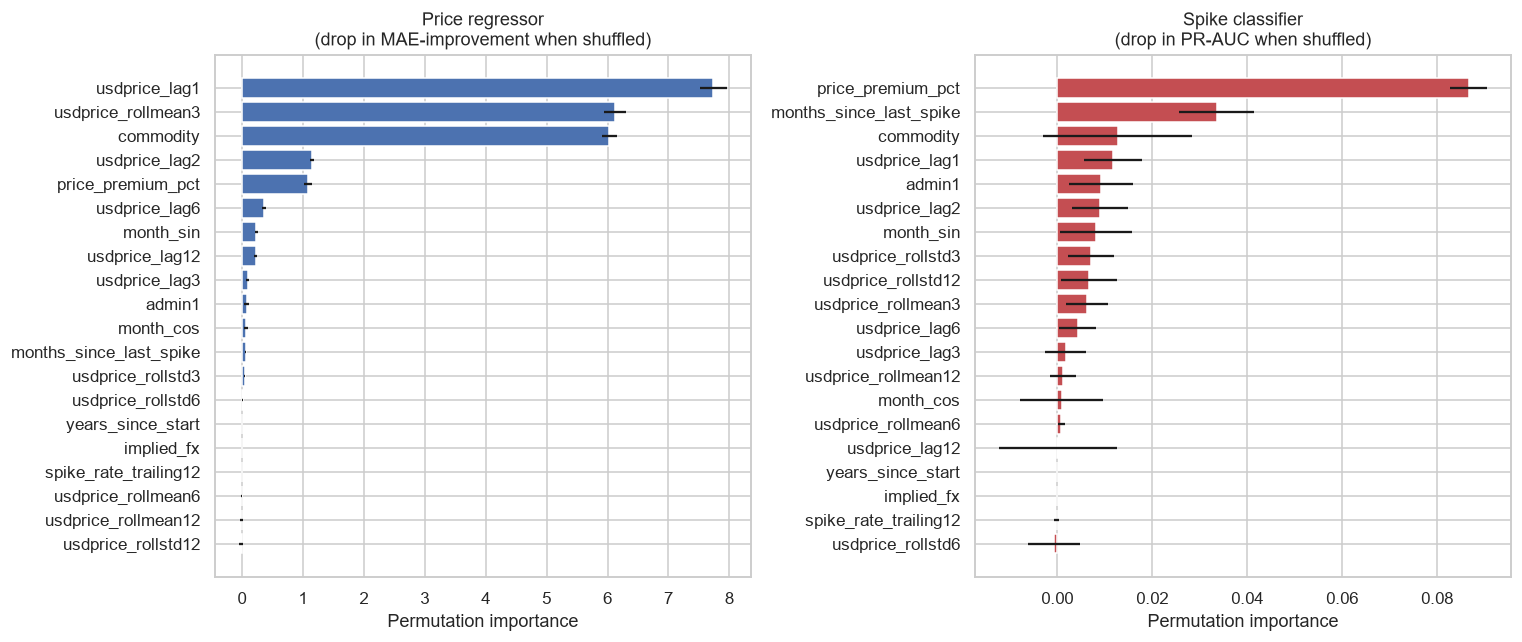

In [9]:
X_reg_test = reg_test[NUM + CAT]
y_reg_test = reg_test[reg_cfg['target']]

perm_reg = permutation_importance(reg_model, X_reg_test, y_reg_test, n_repeats=10,
                                   random_state=42, scoring='neg_mean_absolute_error', n_jobs=-1)
perm_reg_df = pd.DataFrame({
    'feature': NUM + CAT, 'importance': perm_reg.importances_mean, 'std': perm_reg.importances_std,
}).sort_values('importance', ascending=False)

X_clf_test = clf_test[NUM + CAT]
y_clf_test = clf_test[clf_cfg['target']]

perm_clf = permutation_importance(clf_model, X_clf_test, y_clf_test, n_repeats=10,
                                   random_state=42, scoring='average_precision', n_jobs=-1)
perm_clf_df = pd.DataFrame({
    'feature': NUM + CAT, 'importance': perm_clf.importances_mean, 'std': perm_clf.importances_std,
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(perm_reg_df['feature'][::-1], perm_reg_df['importance'][::-1],
             xerr=perm_reg_df['std'][::-1], color='#4C72B0')
axes[0].set_title('Price regressor\n(drop in MAE-improvement when shuffled)')
axes[0].set_xlabel('Permutation importance')

axes[1].barh(perm_clf_df['feature'][::-1], perm_clf_df['importance'][::-1],
             xerr=perm_clf_df['std'][::-1], color='#C44E52')
axes[1].set_title('Spike classifier\n(drop in PR-AUC when shuffled)')
axes[1].set_xlabel('Permutation importance')

plt.tight_layout()
plt.show()


For the **price regressor**, recent price level (`usdprice_lag1` and the short rolling means) dominates
— unsurprising, and consistent with why a simple persistence forecast is such a strong benchmark: almost
all of the regressor's usable signal is just "what was the price recently", which persistence already uses
directly and without dilution from the harder-to-learn scale/categorical structure.

For the **spike classifier**, the picture is different — trailing spike history (`spike_rate_trailing12`,
`months_since_last_spike`) and price *volatility* (`usdprice_rollstd*`) carry real weight alongside price
level, which matches intuition: a series that has been unstable recently is more likely to spike again,
regardless of its absolute price level.


## 12.3 Partial dependence — how the prediction responds to a feature, all else equal

Restricted to **numeric** features here — sklearn's categorical PDP support is fragile when mixed with
pandas `category` columns in this version, and permutation importance (§12.2) and SHAP (§12.4) already
cover categorical feature effects (`admin1`, `commodity`) directly.


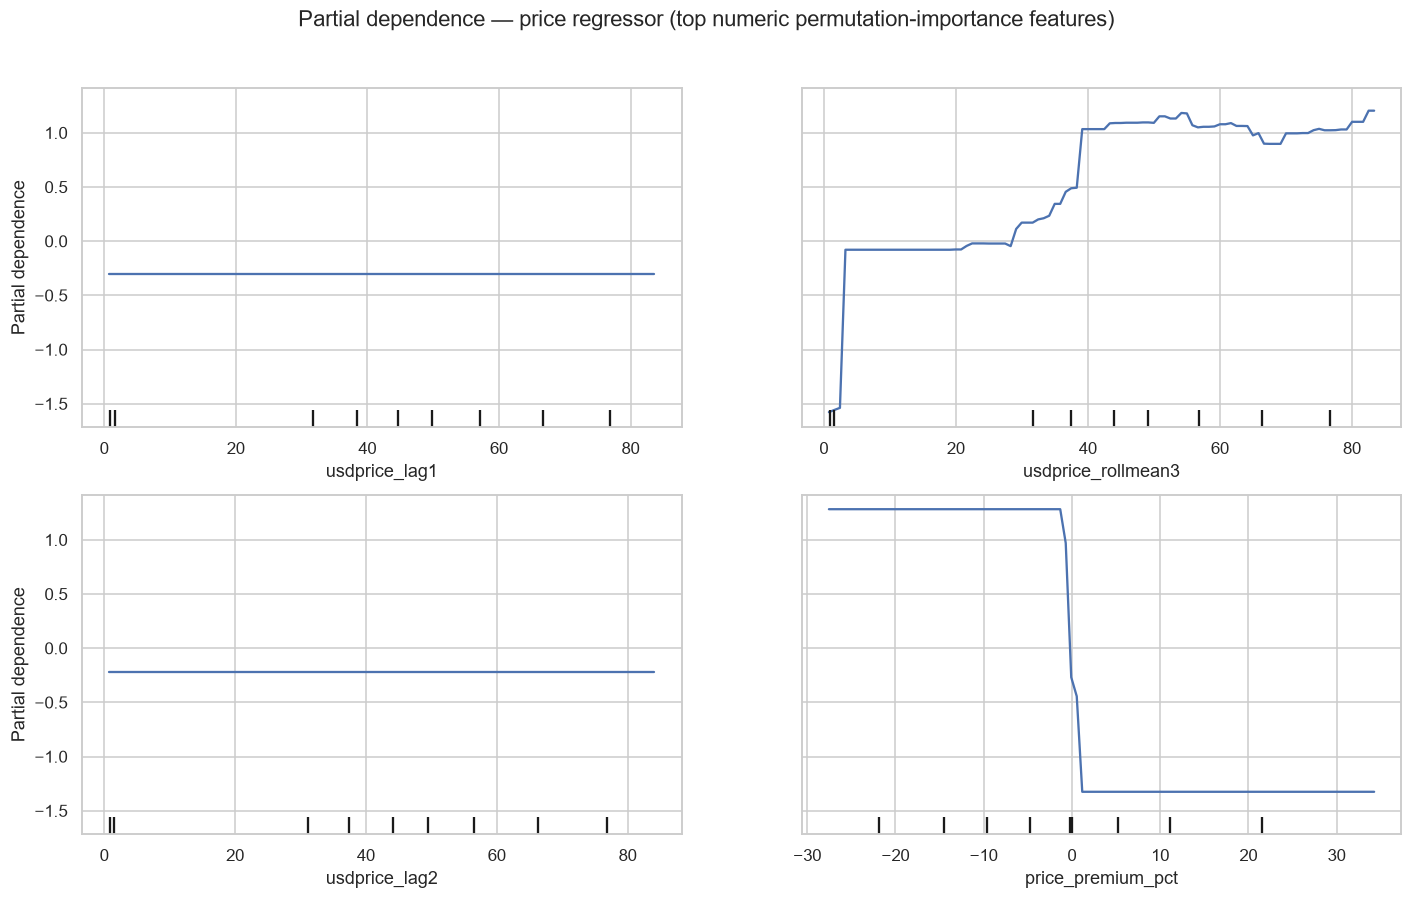

In [10]:
top_reg_features = [f for f in perm_reg_df['feature'] if f in NUM][:4]

fig, ax = plt.subplots(figsize=(13, 8))
PartialDependenceDisplay.from_estimator(reg_model, X_reg_test, top_reg_features, ax=ax, n_cols=2)
plt.suptitle('Partial dependence — price regressor (top numeric permutation-importance features)', y=1.02)
plt.tight_layout()
plt.show()


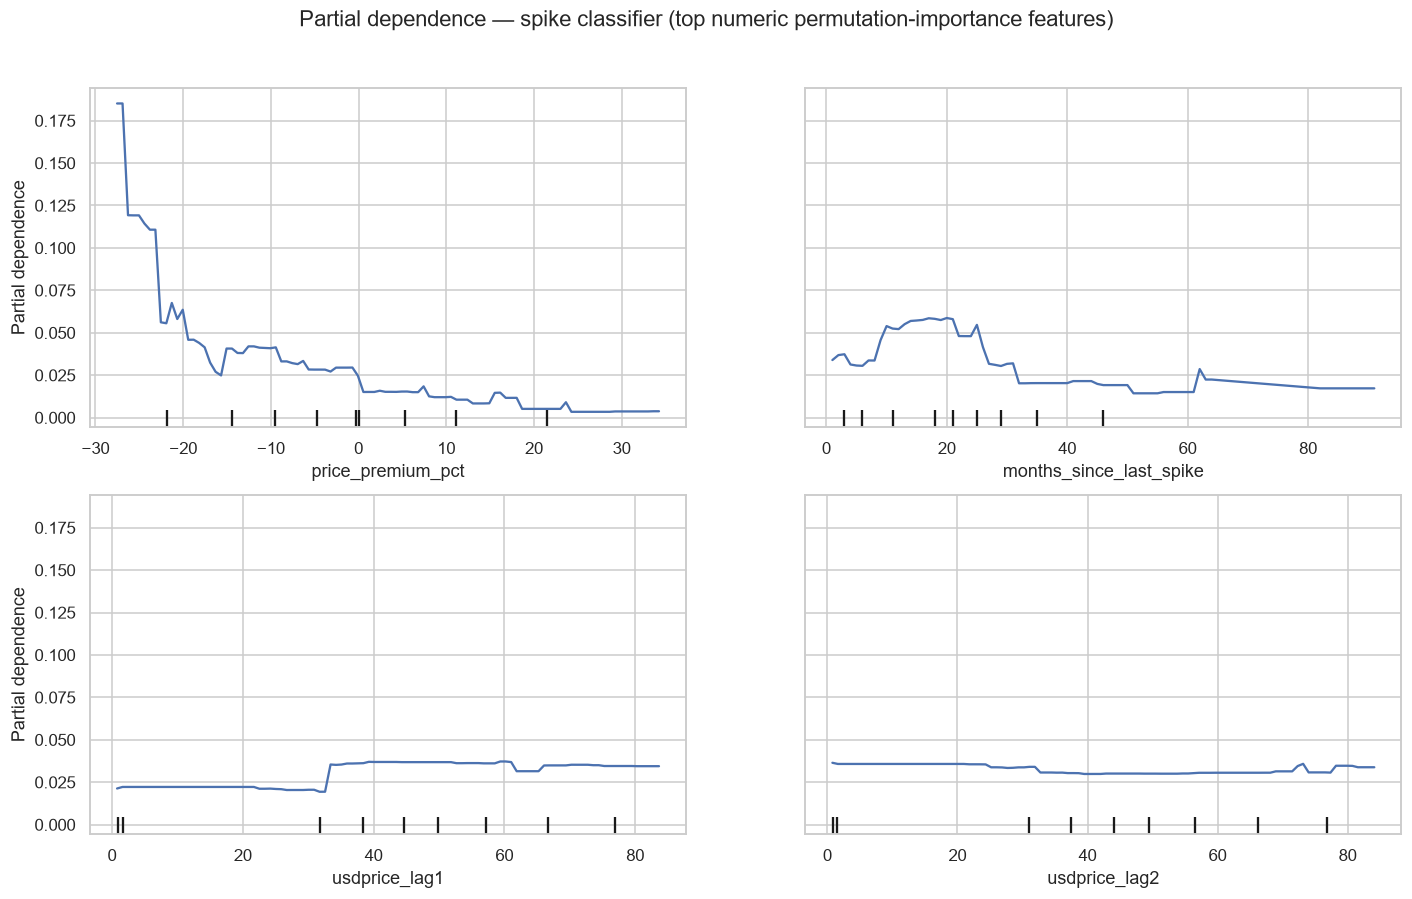

In [11]:
top_clf_features = [f for f in perm_clf_df['feature'] if f in NUM][:4]

fig, ax = plt.subplots(figsize=(13, 8))
PartialDependenceDisplay.from_estimator(clf_model, X_clf_test, top_clf_features, ax=ax, n_cols=2,
                                         response_method='predict_proba', method='brute')
plt.suptitle('Partial dependence — spike classifier (top numeric permutation-importance features)', y=1.02)
plt.tight_layout()
plt.show()


For the price regressor, the dependence on `usdprice_lag1` is close to a straight line through the
plotted range — the model has essentially learned to track recent price, with limited extra curvature
beyond that. For the spike classifier, predicted spike probability rises with `spike_rate_trailing12` and
with recent volatility, in both cases roughly monotonically — the kind of clean, explainable relationship
that gives some confidence the model has picked up a real pattern rather than an artifact.


## 12.4 SHAP values — explaining individual predictions

`HistGradientBoostingRegressor`/`Classifier` use pandas `category` dtype natively for split decisions, which
SHAP's tree explainer doesn't support directly. The categories are re-encoded as integer codes for SHAP's
masker, with a small wrapper that decodes them back to the model's own categories before calling
`predict`/`predict_proba` — this keeps SHAP's internal computations numeric while still querying the exact
fitted model.


In [12]:
import shap

def make_shap_explainer(model, train_df, predict_kind='predict'):
    cat_categories = {c: train_df[c].cat.categories for c in CAT}

    def encode(dfX):
        out = dfX[NUM].astype(float).copy()
        for c in CAT:
            out[c] = dfX[c].cat.codes.astype(float)
        return out[NUM + CAT]

    def predict_fn(arr):
        Xdf = pd.DataFrame(arr, columns=NUM + CAT)
        for c in NUM:
            Xdf[c] = Xdf[c].astype(float)
        for c in CAT:
            codes = Xdf[c].round().astype(int).clip(0, len(cat_categories[c]) - 1)
            Xdf[c] = pd.Categorical.from_codes(codes, categories=cat_categories[c])
        if predict_kind == 'predict_proba':
            return model.predict_proba(Xdf)[:, 1]
        return model.predict(Xdf)

    return encode, predict_fn

N_EXPLAIN = 150
N_BACKGROUND = 50

reg_encode, reg_predict_fn = make_shap_explainer(reg_model, reg_train, 'predict')
X_reg_explain = reg_encode(reg_test[NUM + CAT].sample(N_EXPLAIN, random_state=1).reset_index(drop=True))
X_reg_bg = reg_encode(reg_train[NUM + CAT].sample(N_BACKGROUND, random_state=1).reset_index(drop=True))

reg_masker = shap.maskers.Independent(X_reg_bg.values, max_samples=N_BACKGROUND)
reg_explainer = shap.Explainer(reg_predict_fn, reg_masker, feature_names=NUM + CAT)
reg_shap = reg_explainer(X_reg_explain.values, silent=True)
print('Regressor SHAP values computed:', reg_shap.values.shape)


Regressor SHAP values computed: (150, 20)


In [13]:
clf_encode, clf_predict_fn = make_shap_explainer(clf_model, clf_train, 'predict_proba')
X_clf_explain = clf_encode(clf_test[NUM + CAT].sample(N_EXPLAIN, random_state=1).reset_index(drop=True))
X_clf_bg = clf_encode(clf_train[NUM + CAT].sample(N_BACKGROUND, random_state=1).reset_index(drop=True))

clf_masker = shap.maskers.Independent(X_clf_bg.values, max_samples=N_BACKGROUND)
clf_explainer = shap.Explainer(clf_predict_fn, clf_masker, feature_names=NUM + CAT)
clf_shap = clf_explainer(X_clf_explain.values, silent=True)
print('Classifier SHAP values computed:', clf_shap.values.shape)


Classifier SHAP values computed: (150, 20)


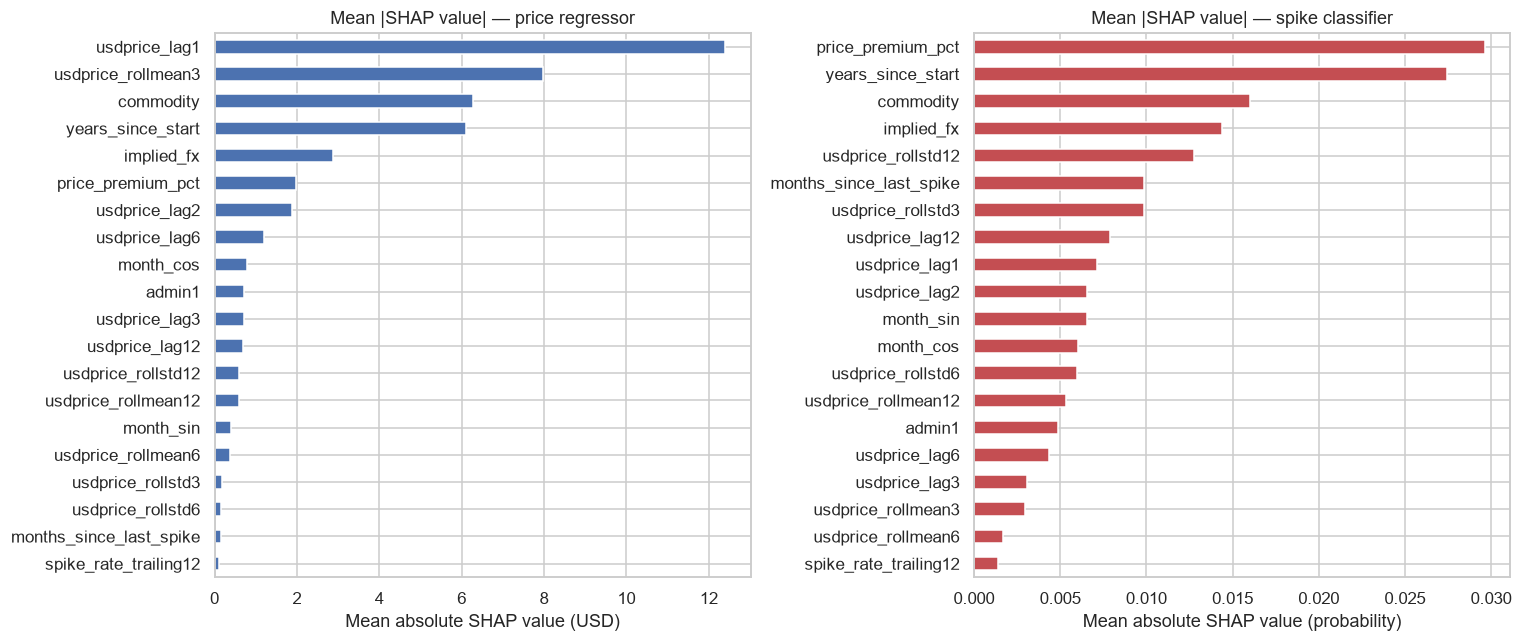

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mean_abs_reg = pd.Series(np.abs(reg_shap.values).mean(axis=0), index=NUM + CAT).sort_values()
mean_abs_reg.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Mean |SHAP value| — price regressor')
axes[0].set_xlabel('Mean absolute SHAP value (USD)')

mean_abs_clf = pd.Series(np.abs(clf_shap.values).mean(axis=0), index=NUM + CAT).sort_values()
mean_abs_clf.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Mean |SHAP value| — spike classifier')
axes[1].set_xlabel('Mean absolute SHAP value (probability)')

plt.tight_layout()
plt.show()


SHAP's ranking (computed on a 150-row sample, distinct from the full permutation importance test set) broadly agrees with §12.2's permutation importance for both models — recent price level dominates the regressor, and spike-history/volatility features dominate the classifier. Two independent methods pointing the same direction is a good sign the finding is real, not a quirk of one technique.

## 12.5 Explaining one specific prediction

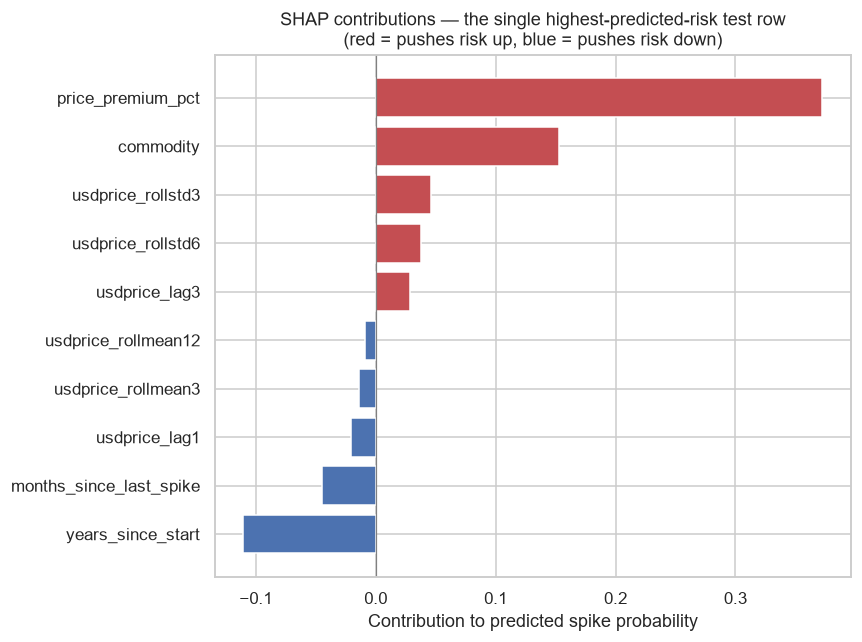

Feature values for this row:
price_premium_pct             -34.633083
commodity                  Maize (white)
usdprice_rollstd3               0.584494
usdprice_rollstd6               1.644888
usdprice_lag3                      28.84
usdprice_rollmean12            29.553333
usdprice_rollmean3             28.543333
usdprice_lag1                      27.87
months_since_last_spike             31.0
years_since_start                  20.25
Name: 24, dtype: object


In [15]:
highest_risk_idx = clf_shap.values.sum(axis=1).argmax()
row = clf_test[NUM + CAT].sample(N_EXPLAIN, random_state=1).reset_index(drop=True).iloc[highest_risk_idx]
row_shap = clf_shap.values[highest_risk_idx]

contrib = pd.Series(row_shap, index=NUM + CAT).sort_values()
top_contrib = pd.concat([contrib.head(5), contrib.tail(5)])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in top_contrib.values]
ax.barh(top_contrib.index, top_contrib.values, color=colors)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('SHAP contributions — the single highest-predicted-risk test row\n(red = pushes risk up, blue = pushes risk down)')
ax.set_xlabel('Contribution to predicted spike probability')
plt.tight_layout()
plt.show()

print('Feature values for this row:')
print(row[top_contrib.index[::-1]])


This is the kind of explanation an analyst reviewing a flagged alert could actually use: not just "the
model says 73% risk", but *which specific factors* — e.g. an elevated `spike_rate_trailing12`, unusually
high recent volatility, a particular region or commodity's historical pattern — pushed this one series to
the top of the risk list.


---
## Summary

- **Permutation importance**, **partial dependence**, and **SHAP** all point to the same conclusions,
  which is reassuring: for the price regressor, recent price level dominates (explaining why persistence is
  such a tough benchmark to beat); for the spike classifier, trailing spike history and recent volatility
  matter alongside price level.
- Partial dependence plots show mostly clean, monotonic relationships for the classifier's top features —
  a sanity check that the model has learned something explainable rather than fitting noise.
- SHAP made it possible to explain one specific high-risk prediction feature-by-feature, which is the kind
  of output an early-warning system would actually need to be usable, not just accurate.
- These findings carry directly into `13 FINAL MODELS`: ship the spike classifier with confidence in its
  reasoning, and treat the price regressor's dependence on recent price level as the reason to pursue the
  log/normalized-target fix identified in `09`/`11` before relying on it over simple persistence.
